<a href="https://colab.research.google.com/github/dldustj0715/machine_learning/blob/main/week02/diabetes_BMI_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/diabetes.csv")
df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


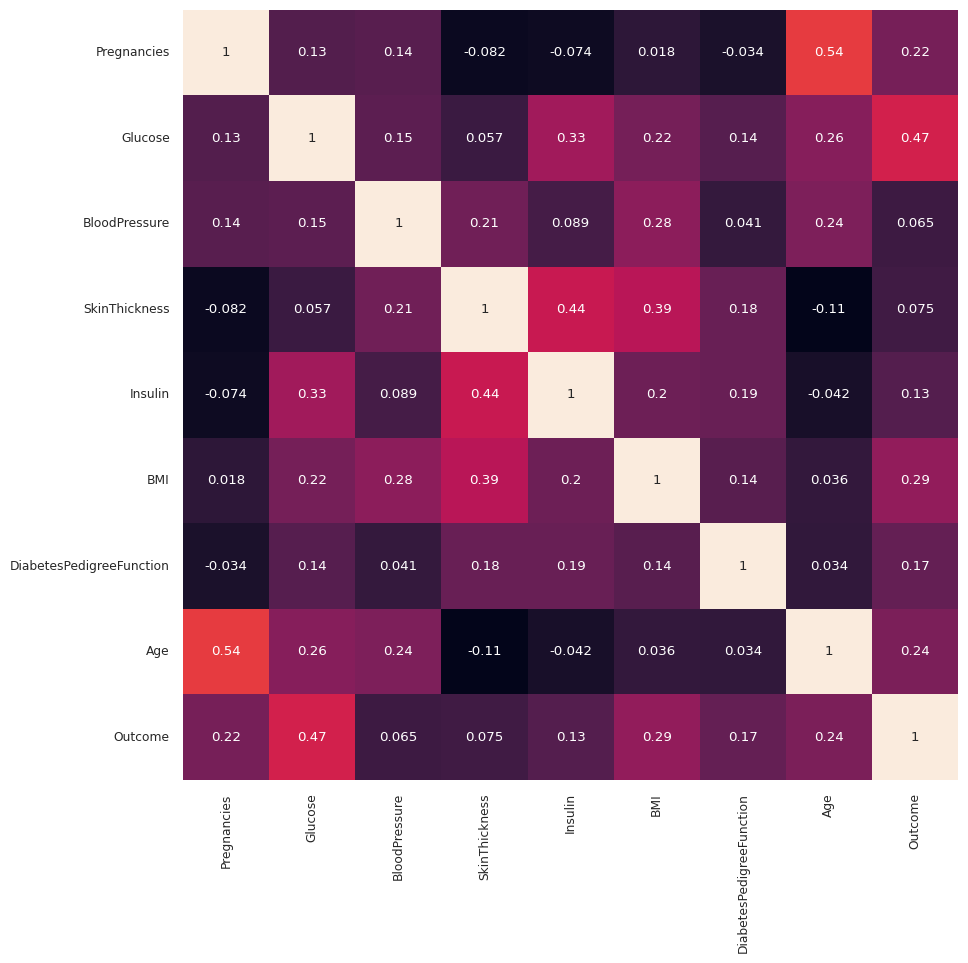

In [4]:
# 상관 관계 행렬
df_corr = df.corr()

# 히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()


## 입력 데이터(X)와 target(y) 설정

- 예측할 값: `BMI`
- 기존 classification 정답인 `Outcome`은 입력 변수에서 제외합니다.


In [5]:
X = df.drop(['BMI', 'Outcome'], axis=1)
X.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,0.627,50
1,1,85,66,29,0,0.351,31
2,8,183,64,0,0,0.672,32
3,1,89,66,23,94,0.167,21
4,0,137,40,35,168,2.288,33


In [6]:
y = df['BMI']
y.head()


,BMI
0,33.6
1,26.6
2,23.3
3,28.1
4,43.1


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=12
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(614, 7) (614,)
(154, 7) (154,)


## 1. Linear Regression


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

ly_preds = model.predict(X_test)

mse = mean_squared_error(y_test, ly_preds)
rmse = np.sqrt(mse)

print("평균제곱오차(MSE):", mse)
print("평균제곱근오차(RMSE):", rmse)


평균제곱오차(MSE): 51.578866344300216
평균제곱근오차(RMSE): 7.181842823697844


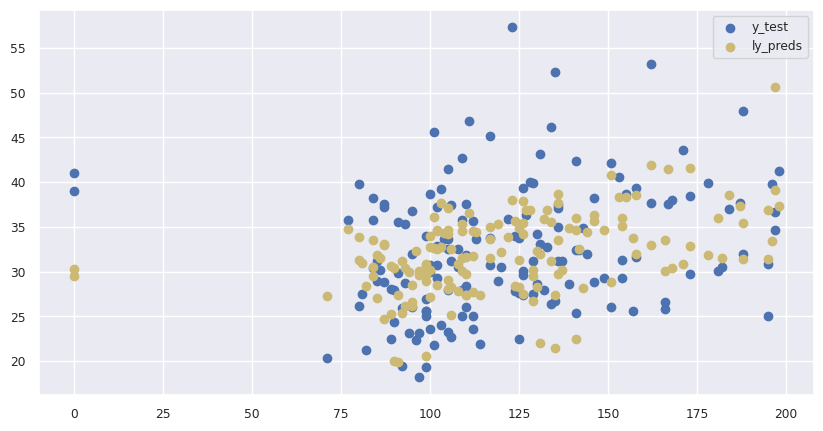

In [9]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Glucose'], y_test, label='y_test')
plt.scatter(X_test['Glucose'], ly_preds, c='y', label='ly_preds')
plt.legend()
plt.show()


## 2. Decision Tree Regression


In [10]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

dy_preds = model.predict(X_test)

mse = mean_squared_error(y_test, dy_preds)
rmse = np.sqrt(mse)

print("평균제곱오차(MSE):", mse)
print("평균제곱근오차(RMSE):", rmse)


평균제곱오차(MSE): 98.48902597402596
평균제곱근오차(RMSE): 9.924163741798397


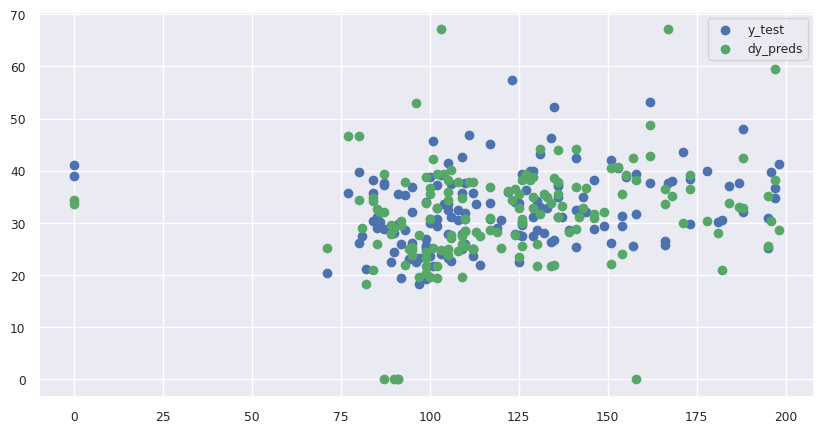

In [11]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Glucose'], y_test, label='y_test')
plt.scatter(X_test['Glucose'], dy_preds, c='g', label='dy_preds')
plt.legend()
plt.show()


## 3. Random Forest Regression


In [12]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

ry_preds = model.predict(X_test)

mse = mean_squared_error(y_test, ry_preds)
rmse = np.sqrt(mse)

print("평균제곱오차(MSE):", mse)
print("평균제곱근오차(RMSE):", rmse)


평균제곱오차(MSE): 41.736899922077924
평균제곱근오차(RMSE): 6.460410197663761


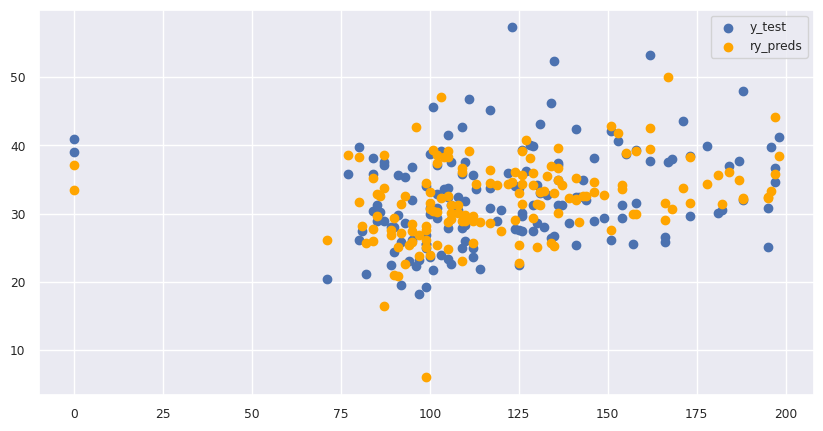

In [13]:
plt.figure(figsize=(10,5))
plt.scatter(X_test['Glucose'], y_test, label='y_test')
plt.scatter(X_test['Glucose'], ry_preds, c='orange', label='ry_preds')
plt.legend()
plt.show()
